In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Dataset.csv")
print(df.head())


   Participant_ID survey_date region country  ip_latitude  ip_longitude  \
0       862217754  02/12/2020      ?      US      42.3690      -88.0651   
1         2363592  02/07/2020     AF      ZA     -26.2870       28.2427   
2         2570172  05/07/2020     AF      ZA     -26.2019       28.0273   
3         2812446  13/06/2020     AF      ZA     -33.8268       18.4772   
4         2867850  29/06/2020     AF      ZA     -26.3120       28.1024   

   gender    age  height  weight  ...  heart_disease lung_disease diabetes  \
0    male  30_40     180      98  ...              0            0        0   
1    male  30_40     168      66  ...              0            0        1   
2  female  60_70     172      86  ...              0            0        0   
3    male  40_50     172     140  ...              1            0        1   
4    male  20_30     186      78  ...              0            0        0   

  hiv_positive other_chronic  nursing_home  health_worker  risk_infection  \
0  

TASK 1: understand and clean the data

In [6]:
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 5789 entries, 0 to 5788
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Participant_ID          5789 non-null   int64  
 1   survey_date             5789 non-null   str    
 2   region                  5774 non-null   str    
 3   country                 5786 non-null   str    
 4   ip_latitude             5789 non-null   float64
 5   ip_longitude            5789 non-null   float64
 6   gender                  5789 non-null   str    
 7   age                     5789 non-null   str    
 8   height                  5789 non-null   int64  
 9   weight                  5789 non-null   int64  
 10  bmi                     5789 non-null   float64
 11  blood_type              5689 non-null   str    
 12  insurance               4497 non-null   str    
 13  income                  4636 non-null   str    
 14  smoking                 5753 non-null   str    
 15

Participant_ID               0
survey_date                  0
region                      15
country                      3
ip_latitude                  0
ip_longitude                 0
gender                       0
age                          0
height                       0
weight                       0
bmi                          0
blood_type                 100
insurance                 1292
income                    1153
smoking                     36
alcohol                      0
cocaine                   4359
contacts_count              42
public_transport_count    1217
working                     28
worried                   1271
covid19_positive             0
covid19_symptoms             0
covid19_contact              0
asthma                       0
kidney_disease               0
liver_disease                0
compromised_immune           0
heart_disease                0
lung_disease                 0
diabetes                     0
hiv_positive                 0
other_ch

We have 5789 rows and have identified:
- "region", "country", "blood_type", "insurance", "income", "smoking", "cocaine", "contacts_count", "public_transport_count", "working", and "worried" variables contain null values

In [5]:
#look at rows with issues
for column in df.columns:
    print(column)
    print(df[column].unique())
    print()

Participant_ID
[862217754   2363592   2570172 ... 863671635 863783472 877539423]

survey_date
<StringArray>
['02/12/2020', '02/07/2020', '05/07/2020', '13/06/2020', '29/06/2020',
 '04/07/2020', '07/07/2020', '22/05/2020', '06/04/2020', '21/05/2020',
 ...
 '20/04/2020', '24/04/2020', '01/05/2020', '22/04/2020', '05/05/2020',
 '03/05/2020', '11/05/2020', '25/03/2020', '26/03/2020', '24/03/2020']
Length: 120, dtype: str

region
<StringArray>
['?', 'AF', 'AS', 'EU', nan, 'N-A', 'OC', 'SA']
Length: 8, dtype: str

country
<StringArray>
['US', 'ZA', 'MZ', 'EG', 'IN', 'IL', 'JP', 'KZ', 'ID', 'PH', 'HK', 'IQ', 'IR',
 'AZ', 'MO', 'PK', 'MY', 'SA', 'GB', 'MK', 'PT', 'NO', 'IE', 'NL', 'DE', 'FR',
 'IT', 'BE', 'CZ', 'GR', 'SE', 'SI', 'FI', 'BA', 'ES', 'HU', 'HR', 'JE', 'RO',
 'RU', 'BG', 'CA', 'GT', 'MX', 'KY', 'BS', 'NZ', 'AU', 'BR', 'CL', 'AR', 'CO',
 'PE', 'MA', 'AE', 'BD', 'QA', 'TR', 'BH', 'GE', 'AT', 'PL', 'CH', 'MD', 'AD',
 'RS', 'SK', 'MT', 'DK', 'DO', 'BM', 'PA', 'HN', 'PR', 'CR', 'EC',  n

In [ ]:
import pandas as pd

for column in df.select_dtypes(include="number").columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"{column}:")
    print(f"Number of outliers: {len(outliers)}")
    print()


Participant_ID:
Number of outliers: 917

ip_latitude:
Number of outliers: 673

ip_longitude:
Number of outliers: 924

height:
Number of outliers: 51

weight:
Number of outliers: 170

bmi:
Number of outliers: 258

alcohol:
Number of outliers: 389

cocaine:
Number of outliers: 352

contacts_count:
Number of outliers: 626

public_transport_count:
Number of outliers: 410

worried:
Number of outliers: 46

covid19_positive:
Number of outliers: 0

covid19_symptoms:
Number of outliers: 997

covid19_contact:
Number of outliers: 989

asthma:
Number of outliers: 757

kidney_disease:
Number of outliers: 63

liver_disease:
Number of outliers: 44

compromised_immune:
Number of outliers: 345

heart_disease:
Number of outliers: 182

lung_disease:
Number of outliers: 135

diabetes:
Number of outliers: 469

hiv_positive:
Number of outliers: 23

other_chronic:
Number of outliers: 378

nursing_home:
Number of outliers: 21

health_worker:
Number of outliers: 490

risk_infection:
Number of outliers: 0

risk

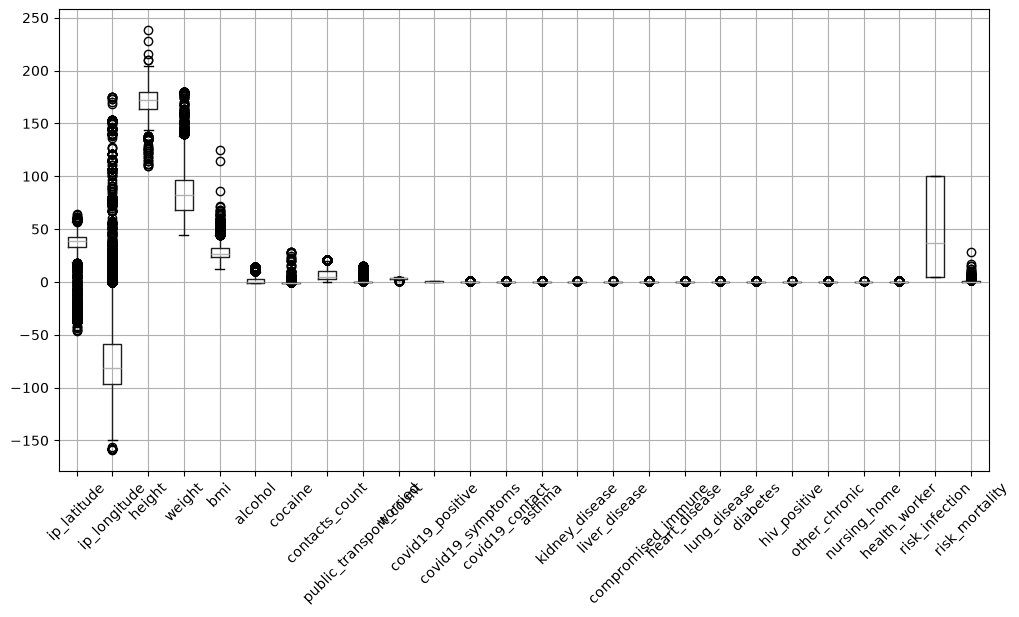

In [12]:
import matplotlib.pyplot as plt
#no need to plot participant ID
outlier = df.select_dtypes(include="number").drop(columns=["Participant_ID"])

outlier.boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()


We must decide if we wish to delete or replace these values

In [ ]:
#replace NaN and ? values with Unkown
df["region"] = df["region"].replace("?",pd.NA)
df["region"].isna().sum()

np.int64(27)

TASK 2: After data is cleaned, proceed below

In [ ]:
#average contacts_count of a patient from the US who is COVID-19 positive
df[(df["country"] == "US") & (df["covid19_positive"] == 1)]["contacts_count"].mean()

np.float64(8.24438902743142)

In [ ]:
#covid 19 positive counts per country
df[df["covid19_positive"] == 1]["country"].value_counts()

country
US    1627
BR     164
GB     132
CA      61
MX      40
      ... 
ET       1
PS       1
CZ       1
TH       1
PA       1
Name: count, Length: 73, dtype: int64

In [ ]:
#number heakth workers
df["health_worker"].sum()

np.int64(490)

In [ ]:
#health worker and covid positive
df[(df["health_worker"] == 1) & (df["covid19_positive"] == 1)].shape[0] #shape[0] means number of rows

182

In [ ]:
#average mortality risk per country (top 5)
df.groupby("country")["risk_mortality"].mean().sort_values(ascending=False)


country
AD    3.994000
BS    2.273000
AW    2.171000
AM    1.923500
IR    1.787500
        ...   
BH    0.062500
FI    0.056333
MT    0.050000
KE    0.050000
JE    0.050000
Name: risk_mortality, Length: 94, dtype: float64